# Weekly Sales Forecasting — six time-series models compared

**Author:** Fordrane Albert Okumu · **Tools:** Python (pandas, statsmodels, Prophet, scikit-learn, matplotlib)
**Companion:** the classical models rebuilt in base R live in [`R/sales_forecasting.R`](../R/sales_forecasting.R).

---

## 0. Why forecasting matters, especially for dairy

A dairy manufacturer has to decide **how much yoghurt to produce next week** before it knows how much will sell. The product has a short shelf life, so a forecast error costs money in both directions:

| Error | Consequence |
|---|---|
| **Over-forecast** | Excess stock → expiry, write-offs, markdowns, wasted milk |
| **Under-forecast** | Stock-outs → lost sales, unhappy retailers, shelf space handed to competitors |

A good weekly forecast feeds **production planning, milk procurement, distribution and S&OP**. This notebook builds and compares **six forecasting models**, from a simple benchmark to machine learning, and explains when each one works and why.

### The data

The data is a **synthetic** weekly unit-sales series for a yoghurt portfolio (Jan 2021 – Sep 2026, 300 weeks), generated by [`data/generate_sales.py`](../data/generate_sales.py). It has the features real FMCG sales have:

* **Trend:** steady volume growth, plus a **structural break** (a level drop after a July 2024 price increase)
* **Yearly seasonality:** school-holiday peaks (April, August, December), a January slump, a softer long-rains period
* **Holidays:** Christmas / New Year and Easter uplift
* **Promotions:** planned trade promotions that lift sales, followed by a small **post-promo dip** (retailers and shoppers stocked up)
* **Autocorrelated noise:** shocks that persist for a few weeks

Promotions, holidays and the price change are **known in advance** by the commercial team, so they're used as future-known inputs (*exogenous regressors*), just as in a real S&OP process.

## 1. Setup and data

In [1]:
import sys, warnings, logging
from pathlib import Path
warnings.filterwarnings("ignore")
for _n in ("cmdstanpy", "prophet", "prophet.plot"): logging.getLogger(_n).disabled = True

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

ROOT = Path.cwd().parent if Path.cwd().name == "python" else Path.cwd()
sys.path.insert(0, str(ROOT / "python"))
import models as M

OUT = ROOT / "outputs" / "python"; OUT.mkdir(parents=True, exist_ok=True)
TEAL, AMBER, GREY, RED = "#0f766e", "#b45309", "#94a3b8", "#b91c1c"
COLORS = {"Seasonal naive": GREY, "Holt-Winters (ETS)": "#2563eb", "Theta": "#7c3aed",
          "SARIMAX + Fourier": AMBER, "Prophet": "#db2777", "Gradient boosting": "#65a30d", "Ensemble": TEAL}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "font.size": 10})

df = M.add_regressors(pd.read_csv(ROOT / "data" / "weekly_sales.csv", parse_dates=["week"]))
print(f"{len(df)} weeks: {df.week.min():%d %b %Y} - {df.week.max():%d %b %Y} | missing weeks: "
      f"{len(pd.date_range(df.week.min(), df.week.max(), freq='W-MON')) - len(df)} | missing values: {df.isna().sum().sum()}")
df.head()

300 weeks: 04 Jan 2021 - 28 Sep 2026 | missing weeks: 0 | missing values: 0


,week,units,promo,holiday,post_promo,price_step
0,2021-01-04,9621,0,0,0,0
1,2021-01-11,8935,0,0,0,0
2,2021-01-18,9242,0,0,0,0
3,2021-01-25,10293,0,0,0,0
4,2021-02-01,10887,0,0,0,0


**Data checks:** the series has **no missing weeks and no missing values**. Time-series models assume evenly spaced observations, so gaps would have to be filled first. `post_promo` (the week after a promotion) and `price_step` (after the July 2024 price increase) are derived regressors.

## 2. Look at the series

Always plot before modelling. The eye picks up trend, seasonality, outliers and breaks faster than any test.

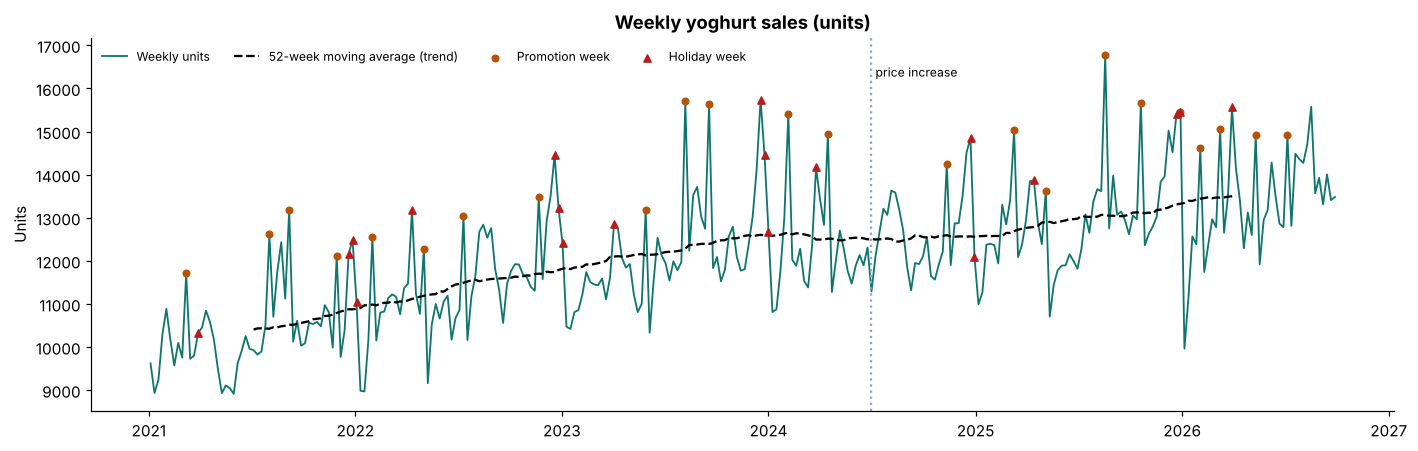

In [2]:
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(df.week, df.units, color=TEAL, lw=1.2, label="Weekly units")
ax.plot(df.week, df.units.rolling(52, center=True).mean(), color="black", lw=1.5, ls="--", label="52-week moving average (trend)")
ax.scatter(df.week[df.promo == 1], df.units[df.promo == 1], color=AMBER, s=18, zorder=3, label="Promotion week")
ax.scatter(df.week[df.holiday == 1], df.units[df.holiday == 1], color=RED, marker="^", s=22, zorder=3, label="Holiday week")
ax.axvline(pd.Timestamp("2024-07-01"), color=GREY, ls=":"); ax.text(pd.Timestamp("2024-07-08"), df.units.max() * .97, "price increase", fontsize=8)
ax.set(title="Weekly yoghurt sales (units)", ylabel="Units"); ax.legend(frameon=False, ncol=4, fontsize=8)
fig.tight_layout(); fig.savefig(OUT / "01_series.png", dpi=150); plt.show()

**What we see:**

* An upward **trend**, with a visible **step down** after the July 2024 price increase, followed by renewed growth.
* A repeating **yearly pattern**: a December peak, a January dip and mid-year bumps.
* **Promotion weeks** (orange) sit above the surrounding weeks, and **holiday weeks** (red) cluster at the December peak and at Easter.
* The size of the seasonal swings grows with the level of the series. That means seasonality is **multiplicative**, so we model **log(units)**, which turns multiplicative effects into additive ones.

## 3. Decompose the series (STL)

**STL** (Seasonal-Trend decomposition using LOESS) splits log sales into **trend + seasonal + remainder**. The **strength** of trend and seasonality (Hyndman's measures, 0–1) tells us which components models must capture.

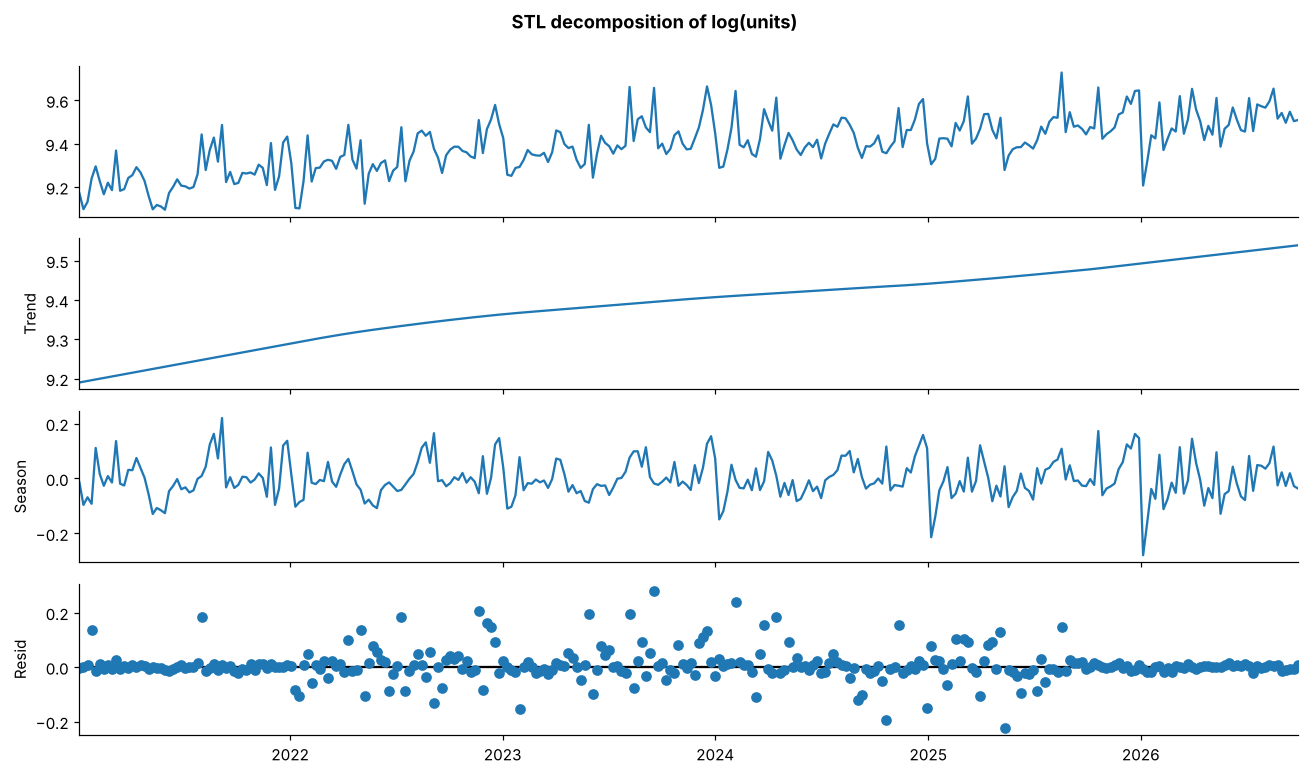

Strength of trend: 0.69 | strength of yearly seasonality: 0.52


In [3]:
y_log = pd.Series(np.log(df.units.values), index=df.week)
stl = STL(y_log, period=52, robust=True).fit()
fig = stl.plot(); fig.set_size_inches(12, 7); fig.suptitle("STL decomposition of log(units)", y=1.0, fontweight="bold")
fig.tight_layout(); fig.savefig(OUT / "02_stl.png", dpi=150); plt.show()
F_trend = max(0, 1 - stl.resid.var() / (stl.trend + stl.resid).var())
F_season = max(0, 1 - stl.resid.var() / (stl.seasonal + stl.resid).var())
print(f"Strength of trend: {F_trend:.2f} | strength of yearly seasonality: {F_season:.2f}")

**Interpretation:** trend strength is about **0.69** and seasonal strength about **0.52** (on a 0–1 scale, where 1 means the component explains all the variation once noise is removed). Both are substantial, so a model that ignores either one will fail. The remainder still has spikes: those are promotions and holidays that a pure seasonal model can't explain, which is why we also give the models **regressors**.

## 4. Stationarity and autocorrelation

ARIMA-type models need a **stationary** series (constant mean and variance over time). Two complementary tests:

* **ADF:** H₀ = the series has a unit root (*non-stationary*). A small p-value means stationary.
* **KPSS:** H₀ = the series *is* stationary. A small p-value means non-stationary.

Checking with both avoids being misled by one test.

In [4]:
def stationarity(x, name):
    adf_p = adfuller(x.dropna(), autolag="AIC")[1]
    kpss_p = kpss(x.dropna(), regression="c", nlags="auto")[1]
    return {"series": name, "ADF p-value": round(adf_p, 3), "KPSS p-value": round(kpss_p, 3),
            "verdict": "stationary" if adf_p < .05 and kpss_p > .05 else "NOT stationary"}
pd.DataFrame([stationarity(y_log, "log(units)"), stationarity(y_log.diff(), "Δ log(units) (1st difference)")])

,series,ADF p-value,KPSS p-value,verdict
0,log(units),0.658,0.01,NOT stationary
1,Δ log(units) (1st difference),0.000,0.10,stationary


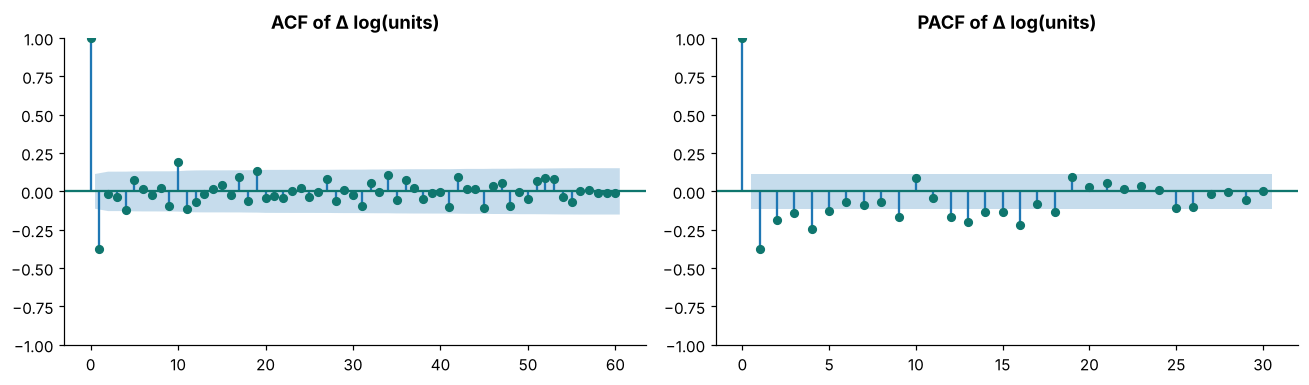

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
plot_acf(y_log.diff().dropna(), lags=60, ax=ax[0], color=TEAL); ax[0].set_title("ACF of Δ log(units)")
plot_pacf(y_log.diff().dropna(), lags=30, ax=ax[1], color=TEAL, method="ywm"); ax[1].set_title("PACF of Δ log(units)")
fig.tight_layout(); fig.savefig(OUT / "03_acf_pacf.png", dpi=150); plt.show()

**Interpretation:**

* **log(units)** is non-stationary because of the trend. After **first differencing** both tests agree it is stationary, so ARIMA needs **d = 1**.
* The **ACF** spike at lag 1 and the remaining structure near **lag 52** show short-term autocorrelation plus yearly seasonality. A seasonal ARIMA with period 52 would be slow and unstable on 5 years of data, so we capture seasonality with **Fourier terms** (smooth sine/cosine waves) instead. This is the standard approach for weekly data.

## 5. How big are the promotion and holiday effects?

A quick look at average sales in promo, post-promo and holiday weeks, relative to the surrounding trend and season.

In [6]:
ratio = df.units / np.exp(stl.trend.values + stl.seasonal.values)
eff = pd.DataFrame({"weeks": [df.promo.sum(), df.post_promo.sum(), df.holiday.sum(),
                              ((df.promo + df.post_promo + df.holiday) == 0).sum()],
                    "avg sales vs expected": [ratio[df.promo == 1].mean(), ratio[df.post_promo == 1].mean(),
                                              ratio[df.holiday == 1].mean(),
                                              ratio[(df.promo + df.post_promo + df.holiday) == 0].mean()]},
                   index=["Promotion week", "Week after promotion", "Holiday week", "Normal week"])
eff["uplift %"] = (eff["avg sales vs expected"] - 1) * 100
eff.round(3)

,weeks,avg sales vs expected,uplift %
Promotion week,23,1.117,11.656
Week after promotion,23,0.965,-3.491
Holiday week,19,1.025,2.482
Normal week,236,1.002,0.181


**Interpretation:** promotion weeks sell well above the trend-and-season baseline, the week *after* a promotion sells below it (the **pantry-loading dip**), and holiday weeks carry their own uplift on top of seasonality. Two consequences:

1. A forecast that ignores the promo calendar will miss every promo week.
2. The *net* gain from a promotion is smaller than its headline uplift. That matters when the commercial team judges promotion ROI.

## 6. How we evaluate models fairly

**Rule 1: never test on data the model has seen.** We hold out the **last 26 weeks** (Apr – Sep 2026) as a test set, fit every model on the data before it, and forecast all 26 weeks in one go. That's what a planner would do at the start of the period.

**Rule 2: one test period can be lucky.** We also run a **rolling-origin backtest**: four forecast origins, each predicting the next **13 weeks** (one quarter), covering the last 52 weeks.

**Metrics:**

| Metric | Formula / meaning | Why use it |
|---|---|---|
| **MAE** | mean of \|actual − forecast\| (units) | Easy to explain: "on average we're off by X units a week" |
| **RMSE** | √mean(error²) | Penalises big misses. Drives **safety stock** |
| **MAPE** | mean of \|error\| / actual (%) | Scale-free; the number planners talk about |
| **MASE** | MAE ÷ in-sample MAE of the seasonal naive | **< 1 = better than "same week last year"** |
| **Bias** | (Σ forecast − Σ actual) / Σ actual | + = over-forecast (waste), − = under-forecast (stock-outs) |

In [7]:
H = 26
train, test = df.iloc[:-H].copy(), df.iloc[-H:].copy()
print(f"Train: {train.week.min():%d %b %Y} - {train.week.max():%d %b %Y} ({len(train)} weeks) | "
      f"Test: {test.week.min():%d %b %Y} - {test.week.max():%d %b %Y} ({len(test)} weeks)")
forecasts, results = {}, {}
def evaluate(name, pred):
    forecasts[name] = np.asarray(pred)
    results[name] = M.metrics(test.units, pred, train.units.values)
    return pd.Series(results[name]).round(2).to_frame(name).T

def plot_fc(name, extra=None):
    fig, ax = plt.subplots(figsize=(12, 3.4))
    hist = train.iloc[-78:]
    ax.plot(hist.week, hist.units, color="black", lw=1, label="Training data")
    ax.plot(test.week, test.units, color="black", lw=1.6, ls="--", label="Actual (test)")
    ax.plot(test.week, forecasts[name], color=COLORS[name], lw=2, label=f"{name} forecast")
    if extra is not None: extra(ax)
    ax.set(title=f"{name}: MAPE {results[name]['MAPE %']:.1f}% · MASE {results[name]['MASE']:.2f}", ylabel="Units")
    ax.legend(frameon=False, fontsize=8, ncol=3)
    fig.tight_layout(); fig.savefig(OUT / f"fc_{name.split()[0].lower().replace('-', '_')}.png", dpi=150); plt.show()

Train: 04 Jan 2021 - 30 Mar 2026 (274 weeks) | Test: 06 Apr 2026 - 28 Sep 2026 (26 weeks)


---
## Model 1 — Seasonal naive (the benchmark)

**Idea:** *next year's week 20 = last year's week 20.*

**Why include such a simple model?** Every sophisticated model must **beat it** to justify its complexity. Many real forecasting systems don't. MASE is defined against it.

**Weakness:** it ignores trend (growth is missed) and copies last year's one-off events (last year's promo week is projected even if there's no promo this year).

,MAE,RMSE,MAPE %,MASE,Bias %
Seasonal naive,1066.5,1375.66,7.65,1.03,-5.79


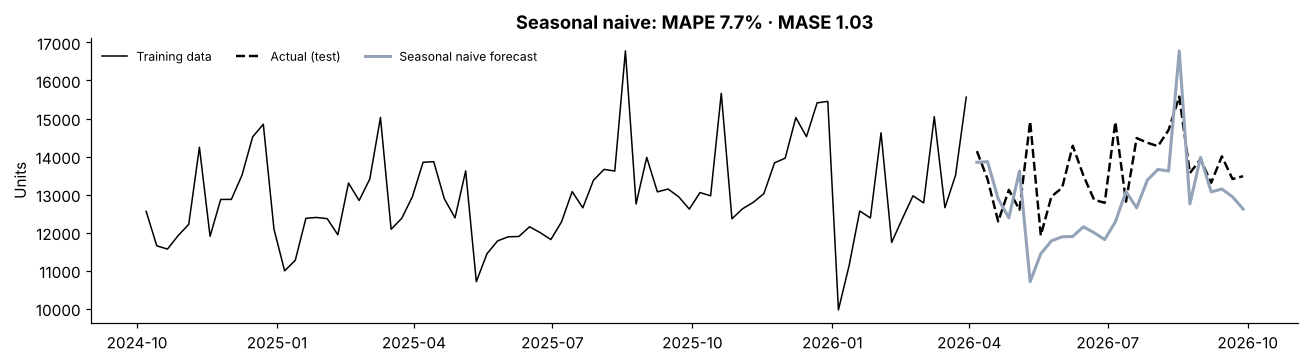

In [8]:
display(evaluate("Seasonal naive", M.seasonal_naive(train, test)))
plot_fc("Seasonal naive")

**Interpretation:** the shape is roughly right because seasonality repeats, but the forecast is **biased low** (it misses a year of growth) and puts spikes where last year's promotions were rather than where this year's are. This is the baseline to beat.

## Model 2 — Holt-Winters exponential smoothing (ETS)

**Idea:** keep three running estimates, each updated by a weighted average of the newest observation and the previous estimate:

* **level** (smoothing weight α)
* **trend**, damped so it flattens rather than growing forever (β, φ)
* **seasonal index** for each of the 52 weeks (γ)

Recent data gets more weight. It's fast, robust and the workhorse of many demand-planning systems. **Weakness:** it can't use promo or holiday calendars.

{'smoothing_level': np.float64(0.0), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(0.0), 'damping_trend': np.float64(0.993)}


,MAE,RMSE,MAPE %,MASE,Bias %
Holt-Winters (ETS),653.5,921.0,4.66,0.63,-3.58


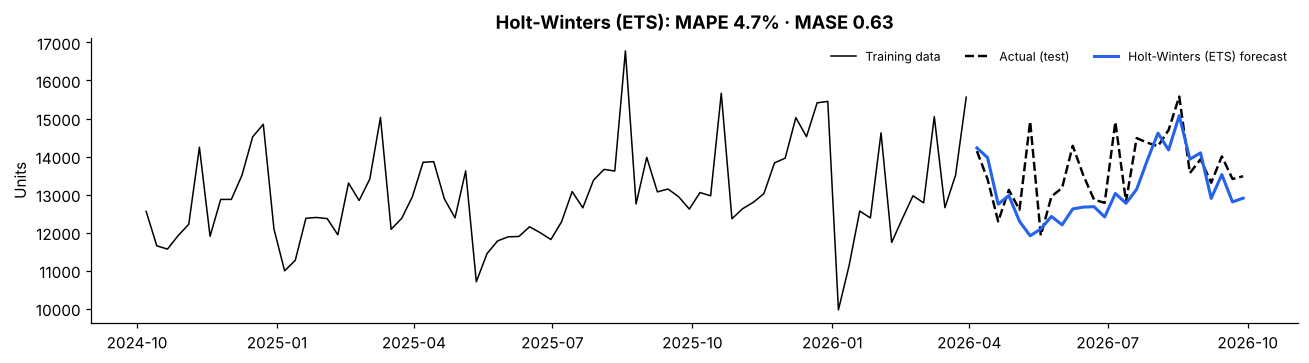

In [9]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
hw = ExponentialSmoothing(np.log(train.units.values), trend="add", damped_trend=True, seasonal="add",
                          seasonal_periods=52).fit(optimized=True)
print({k: round(v, 3) for k, v in hw.params.items() if k in ("smoothing_level", "smoothing_trend", "smoothing_seasonal", "damping_trend")})
display(evaluate("Holt-Winters (ETS)", M.holt_winters(train, test)))
plot_fc("Holt-Winters (ETS)")

**Interpretation:** ETS captures trend and seasonality, a clear improvement on the benchmark (MASE well below 1). The smoothing weights (α, β, γ) are estimated at almost **zero**. That means the optimiser decided the level, trend and seasonal pattern are *stable*, so it treats them as nearly fixed rather than chasing recent noise (damping φ ≈ 0.99 keeps the trend almost linear). It still **can't anticipate promotions**: the forecast is smooth exactly where actual sales spike.

## Model 3 — Theta method

**Idea:** remove seasonality, then combine two "theta lines": a **long-run linear trend** and a **simple exponential smoothing** of recent levels. Put the seasonality back at the end.

Theta famously **won the M3 forecasting competition**. It's simple, fast and hard to beat on trended data. **Weakness:** like ETS, it has no regressors.

,MAE,RMSE,MAPE %,MASE,Bias %
Theta,565.14,808.56,4.07,0.55,-0.7


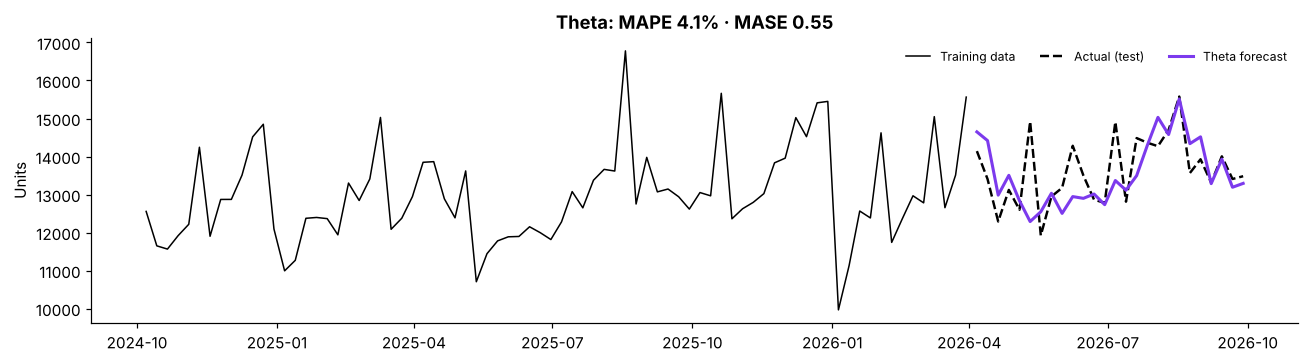

In [10]:
display(evaluate("Theta", M.theta(train, test)))
plot_fc("Theta")

**Interpretation:** Theta gets the overall level right with very little bias, because its long-run trend line is robust to short-term noise. Like ETS, it misses the promo spikes.

## Model 4 — SARIMAX: regression with ARIMA errors + Fourier seasonality

**Idea:** model log sales as

```
log(units) = drift + Fourier seasonality + β₁·promo + β₂·post_promo + β₃·holiday + β₄·price_step + ARIMA(1,1,1) error
```

* **Fourier terms** (6 sine/cosine pairs) describe the yearly pattern smoothly with only 12 parameters, instead of 52 seasonal dummies.
* **Regressors** let the model *know* the promo and holiday calendar.
* **ARIMA(1,1,1) errors** (d = 1 from the stationarity tests) capture short-term autocorrelation.

The order is chosen by **AIC** on the training data from a small grid.

Best order by AIC: ARIMA(0, 1, 2)


,order,AIC
2,"(0, 1, 2)",-971.6
5,"(1, 1, 2)",-968.5
8,"(2, 1, 2)",-967.9
4,"(1, 1, 1)",-930.9
6,"(2, 1, 0)",-913.9


,coefficient (log),effect on sales %
promo,0.163,17.733
post_promo,-0.064,-6.157
holiday,0.082,8.555
price_step,-0.060,-5.830


,MAE,RMSE,MAPE %,MASE,Bias %
SARIMAX + Fourier,530.88,650.06,3.91,0.51,-0.07


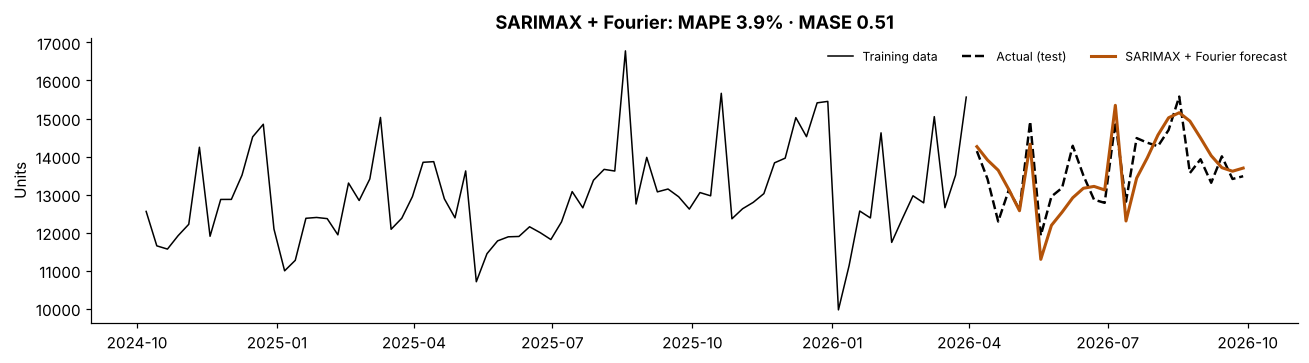

In [11]:
cols = ["promo", "post_promo", "holiday", "price_step"]
Xtr = np.column_stack([M.fourier(train.week), train[cols].values])
grid = []
for p in range(3):
    for q in range(3):
        try:
            fit = SARIMAX(np.log(train.units.values), exog=Xtr, order=(p, 1, q), trend="c").fit(disp=False)
            grid.append({"order": (p, 1, q), "AIC": fit.aic})
        except Exception:
            pass
grid = pd.DataFrame(grid).sort_values("AIC"); best_order = grid.iloc[0].order
print(f"Best order by AIC: ARIMA{best_order}"); display(grid.head(5).round(1))

fit = SARIMAX(np.log(train.units.values), exog=Xtr, order=best_order, trend="c").fit(disp=False)
names = ["drift"] + [f"fourier_{i}" for i in range(12)] + cols
params = pd.Series(fit.params[:len(names)], index=names)
eff = pd.DataFrame({"coefficient (log)": params[cols], "effect on sales %": (np.exp(params[cols]) - 1) * 100})
display(eff.round(3))
display(evaluate("SARIMAX + Fourier", M.sarimax(train, test, order=best_order)))
plot_fc("SARIMAX + Fourier")

**Interpretation:**

* AIC picks **ARIMA(0,1,2)** errors (one difference, two moving-average terms).
* The **regression coefficients** turn straight into business numbers: a promotion week lifts sales by about **+18%**, the following week dips about **−6%**, holiday weeks add about **+9%** and the price increase lowered the base level by about **−6%**. These are very close to the true effects used to generate the data (+18%, −6%, +8%, −6%). The rougher averages in section 5 (+12%, −3.5%, +2.5%) understated them, because STL had already absorbed part of each effect into trend and seasonality. Estimating everything *jointly* is what makes the effects recoverable.
* Knowing the promo calendar, SARIMAX **forecasts the spikes**, the main advantage over ETS and Theta.

## Model 5 — Prophet

**Idea:** Meta's Prophet is a decomposable regression model:

```
y(t) = piecewise-linear trend (automatic changepoints) × yearly seasonality (Fourier) × regressor effects + noise
```

It **detects trend changes automatically** (useful for the price-increase break), handles missing data and holidays well, and its components are easy to explain to non-technical stakeholders.

,MAE,RMSE,MAPE %,MASE,Bias %
Prophet,519.38,666.55,3.82,0.5,-1.15


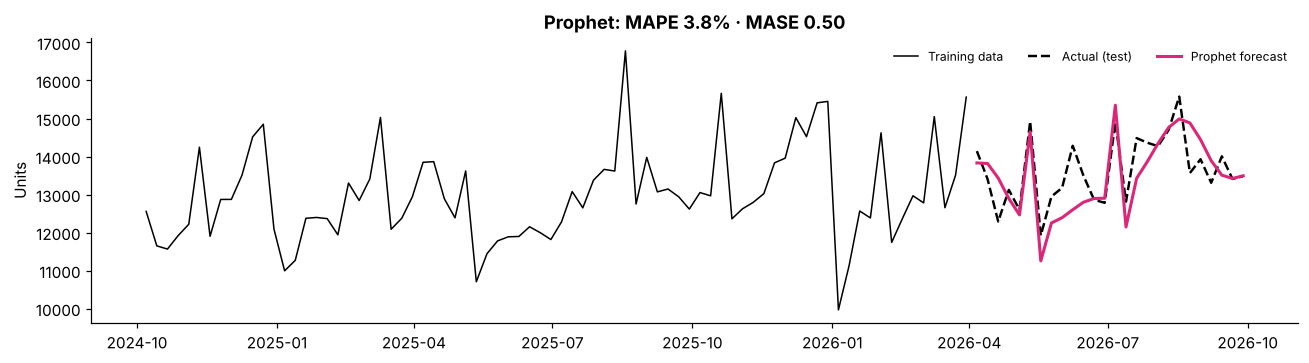

In [12]:
display(evaluate("Prophet", M.prophet(train, test)))
plot_fc("Prophet")

**Interpretation:** Prophet combines a flexible trend, yearly seasonality and the promo/holiday regressors, so it gets both the **level** and the **spikes** right. Its multiplicative mode matches the way seasonal swings scale with volume in this series.

## Model 6 — Gradient boosting (machine learning)

**Idea:** treat forecasting as supervised learning. The target is **year-on-year growth** for the same week, `log(units / units 52 weeks ago)`. Features:

* recent YoY growth at the forecast origin (momentum)
* week of year
* promo / post-promo / holiday / price flags **this year *and* last year**

The flags for last year matter because last year's promo inflated the base we compare against. The forecast is `units 52 weeks ago × e^(predicted growth)`.

**Why this design?** Tree models can't **extrapolate** a trend. Predicting *growth relative to last year* sidesteps that, and every feature is known at forecast time, so there's no leakage.

,MAE,RMSE,MAPE %,MASE,Bias %
Gradient boosting,572.02,727.78,4.2,0.55,0.46


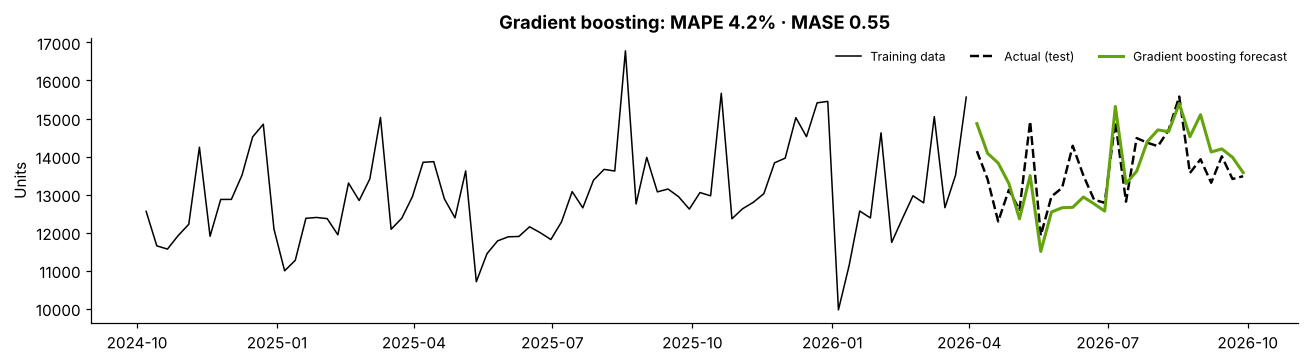

In [13]:
display(evaluate("Gradient boosting", M.gradient_boosting(train, test)))
plot_fc("Gradient boosting")

**Interpretation:** the ML model learns how promo and holiday flags in *both* years shift growth, so it corrects the seasonal-naive problem of copying last year's promo spikes. On this hold-out it beats ETS and matches Theta, but section 8 shows it is less stable across other forecast origins. It relies on a full year of comparable history behind every forecast week, and its accuracy depends on careful feature design.

## Bonus — Ensemble (forecast combination)

**Idea:** average the forecasts of four structurally different models (ETS, SARIMAX, Prophet, gradient boosting). Their errors are partly independent, so averaging cancels some of them out. Combining forecasts is one of the most reliable findings in forecasting research (the M4 and M5 competitions).

,MAE,RMSE,MAPE %,MASE,Bias %
Ensemble,470.59,635.7,3.43,0.45,-1.08


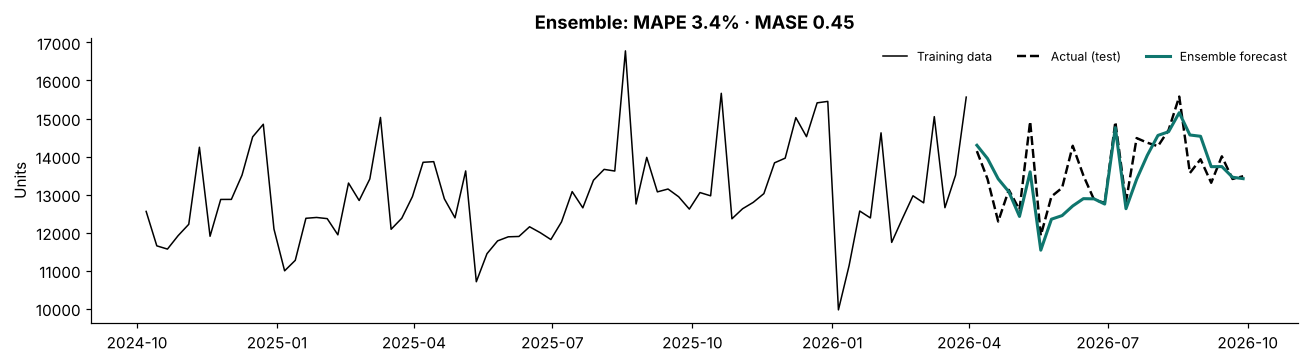

In [14]:
COLORS["Ensemble"] = TEAL
display(evaluate("Ensemble", np.mean([forecasts[m] for m in M.ENSEMBLE_MEMBERS], axis=0)))
plot_fc("Ensemble")

---
## 7. Compare all models on the 26-week hold-out

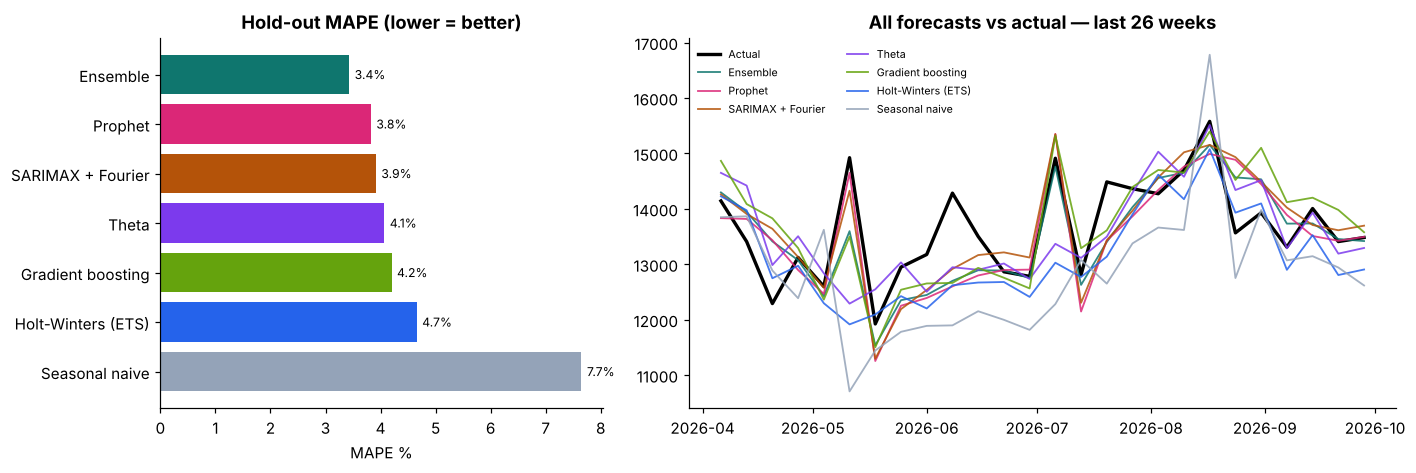

,MAE,RMSE,MAPE %,MASE,Bias %
Ensemble,470.59,635.70,3.43,0.45,-1.08
Prophet,519.38,666.55,3.82,0.50,-1.15
SARIMAX + Fourier,530.88,650.06,3.91,0.51,-0.07
Theta,565.14,808.56,4.07,0.55,-0.70
Gradient boosting,572.02,727.78,4.20,0.55,0.46
Holt-Winters (ETS),653.50,921.00,4.66,0.63,-3.58
Seasonal naive,1066.50,1375.66,7.65,1.03,-5.79


In [15]:
comp = pd.DataFrame(results).T.sort_values("MASE")
comp.to_csv(OUT / "holdout_metrics.csv")
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1, 1.6]})
ax[0].barh(comp.index[::-1], comp["MAPE %"][::-1], color=[COLORS[m] for m in comp.index[::-1]])
for i, v in enumerate(comp["MAPE %"][::-1]): ax[0].text(v + .1, i, f"{v:.1f}%", va="center", fontsize=8)
ax[0].set(title="Hold-out MAPE (lower = better)", xlabel="MAPE %")
ax[1].plot(test.week, test.units, color="black", lw=2.2, label="Actual")
for m in comp.index:
    ax[1].plot(test.week, forecasts[m], color=COLORS[m], lw=1.2, alpha=.85, label=m)
ax[1].set(title="All forecasts vs actual — last 26 weeks"); ax[1].legend(frameon=False, fontsize=7, ncol=2)
fig.tight_layout(); fig.savefig(OUT / "04_model_comparison.png", dpi=150); plt.show()
comp.round(2)

**Hold-out results (Apr – Sep 2026):** the **ensemble** has the lowest error (MAPE **3.4%**, MASE **0.45**), followed by **Prophet** (3.8%) and **SARIMAX** (3.9%), the models that know the promo calendar. SARIMAX also has almost **zero bias** (−0.1%). Theta (4.1%), gradient boosting (4.2%) and ETS (4.7%) follow, and the **seasonal naive** is clearly worst (7.7%, under-forecasting by 5.8%). In the right-hand chart, the regressor-aware models rise with each promo spike while ETS and Theta stay smooth.

## 8. Rolling-origin backtest — is the ranking stable?

Four origins, each forecasting **13 weeks ahead** with models refitted on all data up to that origin.

In [16]:
origins = [len(df) - 52, len(df) - 39, len(df) - 26, len(df) - 13]
rows = []
for o in origins:
    tr, te = df.iloc[:o], df.iloc[o:o + 13]
    fc = {name: f(tr, te) for name, f in M.MODELS.items()}
    fc["Ensemble"] = np.mean([fc[m] for m in M.ENSEMBLE_MEMBERS], axis=0)
    for name, p in fc.items():
        rows.append({"origin": te.week.iloc[0].date(), "model": name, **M.metrics(te.units, p, tr.units.values)})
bt = pd.DataFrame(rows)
bt_summary = bt.groupby("model")[["MAE", "RMSE", "MAPE %", "MASE", "Bias %"]].mean().sort_values("MASE")
bt_summary["wins (best MASE per fold)"] = bt.loc[bt.groupby("origin").MASE.idxmin(), "model"].value_counts().reindex(bt_summary.index).fillna(0).astype(int)
bt_summary.to_csv(OUT / "backtest_metrics.csv")
display(bt.pivot(index="model", columns="origin", values="MAPE %").loc[bt_summary.index].round(1))
bt_summary.round(2)

origin,2025-10-06,2026-01-05,2026-04-06,2026-07-06
model,,,,
Ensemble,2.2,4.6,4.2,2.7
SARIMAX + Fourier,2.5,4.6,4.1,3.9
Prophet,3.2,4.4,4.2,3.6
Gradient boosting,3.2,7.3,4.9,3.8
Theta,5.4,7.1,5.0,3.4
Holt-Winters (ETS),5.7,6.1,5.2,3.8
Seasonal naive,9.0,5.7,8.9,6.4


,MAE,RMSE,MAPE %,MASE,Bias %,wins (best MASE per fold)
model,,,,,,
Ensemble,458.78,589.60,3.42,0.44,-0.20,2
SARIMAX + Fourier,504.78,620.94,3.78,0.48,0.27,1
Prophet,519.13,627.89,3.86,0.50,-0.20,1
Gradient boosting,653.25,842.79,4.81,0.63,1.77,0
Theta,714.88,935.69,5.25,0.69,-0.05,0
Holt-Winters (ETS),722.23,994.62,5.19,0.69,-2.65,0
Seasonal naive,1046.38,1386.28,7.49,1.01,-5.43,0


**How to read this:** the first table shows each model's MAPE at each of the four forecast origins, and the second averages them. A model that is best on one hold-out but weak on other folds was **lucky**. A model that is consistently near the top is **robust**, which matters more for a production planning system than winning a single test.

**Results:**

* The **ensemble** is the most accurate on average (MAPE **3.4%**, MASE **0.44**) and is best or tied-best in two of the four folds. **SARIMAX** (3.8%) and **Prophet** (3.9%) are close behind and very stable. These three models all use the **promo / holiday / price calendar**.
* **Gradient boosting** looked competitive on the single hold-out (4.2%) but is weaker across the backtest (4.8%), especially in the January 2026 fold. It needs a full year of comparable history behind each forecast week, and it struggles when last year's base week was itself unusual. This is the kind of instability that only a backtest reveals.
* **Theta** and **ETS** (about 5.2%) are robust but can't see promotions, and ETS consistently **under-forecasts** (bias about −2.7%).
* Every model beats the **seasonal naive** (7.5%, bias −5.4%).

**Decision:** use the **ensemble** for the production forecast, and keep **SARIMAX** as the explainable model for quantifying promotion and price effects.

## 9. Residual diagnostics for the statistical model

Good forecasting residuals should look like **white noise**: no remaining autocorrelation, centred on zero. The **Ljung-Box test** checks whether autocorrelation is left (H₀: no autocorrelation; p > 0.05 is good).

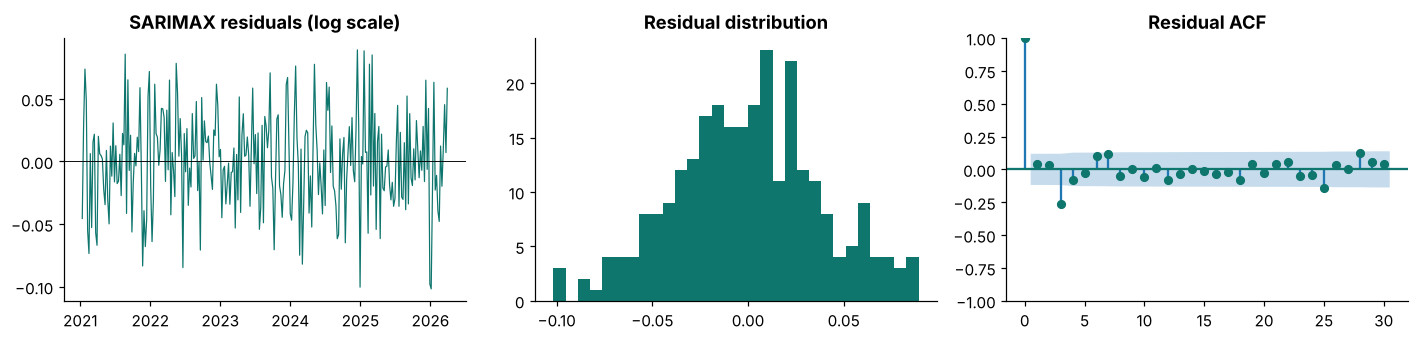

,lb_stat,lb_pvalue
4,21.875,0.000
13,32.685,0.002
26,44.611,0.013


In [17]:
resid = pd.Series(fit.resid[1:])
lb = acorr_ljungbox(resid, lags=[4, 13, 26], return_df=True)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
ax[0].plot(train.week.iloc[1:], resid, color=TEAL, lw=.8); ax[0].axhline(0, color="black", lw=.6); ax[0].set_title("SARIMAX residuals (log scale)")
ax[1].hist(resid, bins=30, color=TEAL); ax[1].set_title("Residual distribution")
plot_acf(resid, lags=30, ax=ax[2], color=TEAL); ax[2].set_title("Residual ACF")
fig.tight_layout(); fig.savefig(OUT / "05_residuals.png", dpi=150); plt.show()
lb.round(3)

**Interpretation:** the residuals are centred on zero with a roughly symmetric distribution, which is good. But the **Ljung-Box p-values are below 0.05**: some short-lag autocorrelation remains, so the model hasn't extracted every predictable pattern. That has two practical consequences:

1. There's still some accuracy to gain, for example a richer error model or an extra regressor.
2. The model's *theoretical* prediction intervals are probably too narrow, because they assume white-noise errors. That's exactly why the final forecast below uses **empirical intervals** built from real backtest errors.

Reporting a failed diagnostic honestly is part of good practice. A model can be the most accurate available and still have room to improve.

## 10. Final forecast — the next 13 weeks (Oct – Dec 2026)

We **refit on all 300 weeks** and forecast the next quarter, which includes the December holiday peak. The promotion plan is taken from the commercial calendar (here: one promo in mid-November and one before Christmas).

**Prediction intervals:** a point forecast alone is not enough for planning. We build **empirical 80% and 95% intervals** from the ensemble's actual percentage errors in the backtest. They're honest because they reflect how wrong the method really was, not a theoretical assumption.

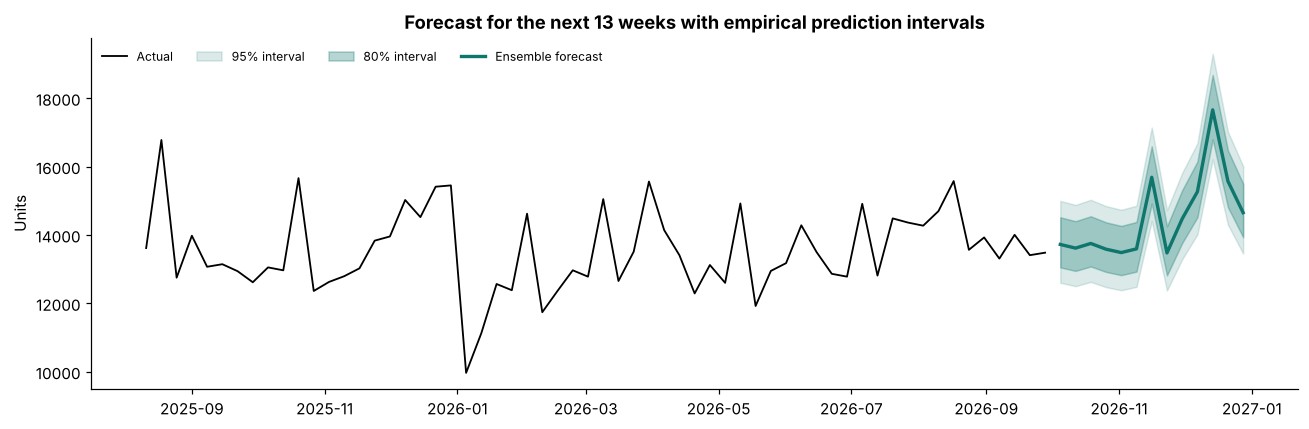

Next-quarter total: 188,546 units (80% range 179,317 – 199,448)


,week,promo,holiday,forecast,lo95,lo80,hi80,hi95
0,2026-10-05,0,0,13723.0,12602.0,13051.0,14516.0,14996.0
1,2026-10-12,0,0,13616.0,12503.0,12949.0,14403.0,14879.0
2,2026-10-19,0,0,13752.0,12628.0,13079.0,14547.0,15028.0
3,2026-10-26,0,0,13584.0,12474.0,12919.0,14370.0,14845.0
4,2026-11-02,0,0,13485.0,12383.0,12825.0,14265.0,14736.0
5,2026-11-09,0,0,13594.0,12483.0,12929.0,14380.0,14855.0
6,2026-11-16,1,0,15688.0,14406.0,14920.0,16595.0,17143.0
7,2026-11-23,0,0,13475.0,12374.0,12816.0,14254.0,14725.0
8,2026-11-30,0,0,14474.0,13291.0,13765.0,15311.0,15817.0
9,2026-12-07,0,0,15268.0,14020.0,14520.0,16150.0,16684.0


In [18]:
future_weeks = pd.date_range(df.week.max() + pd.Timedelta(weeks=1), periods=13, freq="W-MON")
future = pd.DataFrame({"week": future_weeks, "units": np.nan,
                       "promo": [1 if w in (pd.Timestamp("2026-11-16"), pd.Timestamp("2026-12-14")) else 0 for w in future_weeks],
                       "holiday": [1 if (w.month == 12 and w.day >= 18) else 0 for w in future_weeks]})
future = M.add_regressors(pd.concat([df[["week", "units", "promo", "holiday"]], future], ignore_index=True)).iloc[-13:]
final = {m: M.MODELS[m](df, future) for m in M.ENSEMBLE_MEMBERS}
point = np.mean(list(final.values()), axis=0)

ens_bt = bt[bt.model == "Ensemble"]
pct_err = []
for o in origins:
    tr, te = df.iloc[:o], df.iloc[o:o + 13]
    p = np.mean([M.MODELS[m](tr, te) for m in M.ENSEMBLE_MEMBERS], axis=0)
    pct_err.extend((te.units.values - p) / p)
pct_err = np.array(pct_err)
q = {k: np.quantile(pct_err, v) for k, v in {"lo95": .025, "lo80": .10, "hi80": .90, "hi95": .975}.items()}
fc_table = pd.DataFrame({"week": future_weeks.date, "promo": future.promo.values, "holiday": future.holiday.values,
                         "forecast": point.round(0)})
for k, v in q.items():
    fc_table[k] = (point * (1 + v)).round(0)
fc_table.to_csv(OUT / "forecast_next_13_weeks.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 4))
hist = df.iloc[-60:]
ax.plot(hist.week, hist.units, color="black", lw=1.2, label="Actual")
ax.fill_between(future_weeks, fc_table.lo95, fc_table.hi95, color=TEAL, alpha=.15, label="95% interval")
ax.fill_between(future_weeks, fc_table.lo80, fc_table.hi80, color=TEAL, alpha=.30, label="80% interval")
ax.plot(future_weeks, point, color=TEAL, lw=2.2, label="Ensemble forecast")
ax.set(title="Forecast for the next 13 weeks with empirical prediction intervals", ylabel="Units")
ax.legend(frameon=False, fontsize=8, ncol=4)
fig.tight_layout(); fig.savefig(OUT / "06_final_forecast.png", dpi=150); plt.show()
print(f"Next-quarter total: {point.sum():,.0f} units (80% range {fc_table.lo80.sum():,.0f} – {fc_table.hi80.sum():,.0f})")
fc_table

## 11. What the accuracy gain is worth

Forecast error sets **safety stock**: the buffer held to protect service levels. A standard approximation is *safety stock ≈ z × RMSE*, with z = 1.65 for a 95% service level. Comparing the best model with the seasonal-naive benchmark shows the stock (and waste risk) that better forecasting removes, at the same service level.

In [19]:
z = 1.65
ss = pd.DataFrame({"backtest RMSE (units/week)": bt_summary.RMSE})
ss["safety stock (units)"] = z * ss["backtest RMSE (units/week)"]
ss["vs seasonal naive"] = ss["safety stock (units)"] - ss.loc["Seasonal naive", "safety stock (units)"]
ss.round(0)

,backtest RMSE (units/week),safety stock (units),vs seasonal naive
model,,,
Ensemble,590.0,973.0,-1315.0
SARIMAX + Fourier,621.0,1025.0,-1263.0
Prophet,628.0,1036.0,-1251.0
Gradient boosting,843.0,1391.0,-897.0
Theta,936.0,1544.0,-743.0
Holt-Winters (ETS),995.0,1641.0,-646.0
Seasonal naive,1386.0,2287.0,0.0


**Interpretation:** better-performing models need **less safety stock** for the same service level. For a perishable product, every unit of buffer you don't need is a unit that can't expire. In a real business, multiply by unit cost and the number of SKUs to size the benefit of a forecasting programme.

---

## 12. Model guide: which model when?

| Model | Strengths | Weaknesses | Use when |
|---|---|---|---|
| **Seasonal naive** | Zero effort, explainable | No trend, copies last year's events | Always, as the benchmark |
| **Holt-Winters (ETS)** | Fast, robust, adapts to recent data | No regressors | Many SKUs, few known drivers |
| **Theta** | Very robust trend, competition winner | No regressors | Trend-dominated series, quick baselines |
| **SARIMAX + Fourier** | Uses regressors, interpretable effects, proper intervals | Needs stationarity work and diagnostics | Promo/price effects must be quantified |
| **Prophet** | Automatic changepoints, holidays, easy to explain | Can over-fit trend changes | Business series with breaks and holidays |
| **Gradient boosting** | Learns non-linear interactions, scales to many drivers | Can't extrapolate trend by itself; needs feature design | Many series and many drivers (weather, prices, competitors) |
| **Ensemble** | Usually the most accurate and stable | Less interpretable; no single model to explain | Production forecasts |

## 13. Where time-series forecasting is used

* **FMCG & manufacturing:** demand planning, production scheduling, raw-material (milk) procurement, S&OP
* **Retail:** store replenishment, staffing, markdown planning
* **Finance:** revenue and cash-flow forecasting, budgeting, risk (volatility models)
* **Energy & utilities:** electricity load and solar output forecasting
* **Healthcare:** patient admissions, drug stock, disease surveillance (e.g. malaria seasonality)
* **Agriculture:** yield and price forecasting, milk-collection volumes by season
* **Logistics:** fleet and warehouse capacity planning
* **Telecoms & fintech:** network traffic, mobile-money transaction volumes

## 14. Limitations and next steps

* **Synthetic data:** real series also have stock-outs, which *censor* demand (sales ≠ demand), plus data errors and new-product launches.
* **Hierarchical forecasting:** forecast SKU × region × channel and reconcile the totals (MinT, top-down/bottom-up).
* **More drivers:** price elasticity, weather (rainfall affects demand and milk supply), competitor promotions.
* **Probabilistic forecasting:** optimise production against the full forecast distribution and the asymmetric cost of waste vs stock-outs (newsvendor model).
* **Monitoring:** track MAPE and bias every week; retrain on schedule; alert when error drifts.